## Use ABACUS HSE06 band structure to screen for binary small-gap structures

In [1]:
%load_ext aiida
%aiida

Loaded AiiDA DB environment - profile name: bit.

In [2]:
from aiida import orm
from monty.serialization import loadfn, dumpfn
import numpy as np
from aiida_abacus.workflows.band import AbacusBandWorkChain
from aiida_grouppathx import GroupPathX
from tqdm import tqdm
from aiida.engine import submit
from ase.units import Ry

In [3]:
# Load the structures to be calculated
dataset = loadfn('binary_mbj_calc_structures_2025_03_19.json')
print(len(dataset))

665


In [4]:
basepath = GroupPathX('hc-binary-hse-abacus')
structpath = basepath['structures']

Deposit the structures

Sort the nodes based on their number of sites

In [5]:
nodes = [x.get_node() for x in structpath]
nodes.sort(key=lambda x: len(x.sites))

In [6]:
nodes[-1].get_ase()

Atoms(symbols='Ru4F24', pbc=True, cell=[[0.0, 0.0, -4.82221923], [0.0, -8.38575766, 0.0], [-9.05755894, 0.0, 0.0]], masses=...)

## Setting up the calculation

In [117]:
def callback(node, label):
    """Generate process builder"""
    builder = AbacusBandWorkChain.get_builder()
    code = orm.load_code('abacus-3.10lts@sugon-tai-v2')
    
    builder.base.abacus.code = code
    builder.base.abacus.metadata.options = {
        "resources": {
            "num_machines": 1,
            "num_mpiprocs_per_machine": 2,  # use 1 cores per machine
            "num_cores_per_mpiproc": 32,  # Use 32 cores per mpiproc
        },
        "queue_name": 'tyhcnormal',
        "prepend_text": "export OMP_NUM_THREADS=32", # Enable OMP
        "max_wallclock_seconds": 3600 * 24,  # how long it can run before it should be killed
        # 'withmpi': False, # Set withmpi to False in case abacus was compiled without MPI support.
    }
    
    builder.structure = node
    builder.base.kpoints_distance =orm.Float(0.05 * np.pi * 2)
    builder.base.pseudo_family = "SG15_V1.0/dzp"
    builder.base.abacus.parameters = {
        'input':
        {
        "basis_type": "lcao",
        "ecutwfc": 100,
            "dft_functional": "hse",
            "exx_pca_threshold": 1e-3,
            "exx_c_threshold":1e-3,
            "exx_dm_threshold": 1e-3,
            "smearing_sigma": 0.05 / Ry,  # Use a smaller smearing width
        }
    }
    builder.band_settings = {'symprec': 0.1}

    # Relaxation settings
    builder.relax.base.kpoints_distance =orm.Float(0.04 * np.pi * 2)
    builder.relax.base.pseudo_family = "SG15_V1.0/dzp"
    builder.relax.base.abacus.parameters = {
        'input':
        {
        "basis_type": "lcao",
        "ecutwfc": 100,
        "dft_functional": "pbe",
        "calculation": "cell-relax",    
        }
    }
    builder.relax.base.abacus.code = code
    builder.relax.base.abacus.metadata.options = {
        "resources": {
            "num_machines": 1,
            "num_mpiprocs_per_machine": 32,  # use 1 cores per machine
            
        },
        "queue_name": 'tyhcnormal',
        "max_wallclock_seconds": 3600 * 24,  # how long it can run before it should be killed
        # 'withmpi': False, # Set withmpi to False in case abacus was compiled without MPI support.
    }
    builder.metadata.label = label + ' BAND SMALL SIGMA'
    builder.relax.metadata.label = label + ' RELAX'
    builder.base.metadata.label = label + ' NSCF'
    
    running = submit(builder)
    return running, label

In [118]:
workpath = basepath['bandstructure_works']
workpath.get_or_create_group()

(<Group: 'hc-binary-hse-abacus/bandstructure_works' [type core], of user bzhu@bit.edu.cn>,
 False)

In [119]:
from aiida_grouppathx.launch_manager import GroupLauncher

In [120]:
launcher = GroupLauncher(workpath, 60, 
                         callback, source_key_obj_pairs=[(node.label, node) for node in nodes],
                         logfile='launch_2025_5_27_abacus_hse.log')

In [ ]:
launcher.launch_loop()

Total number of running jobs: 44
Total number of jobs to run : 37
Time elapsed to gather jobs: 0.29 seconds
Slot usage: 44/60
Launching 16 jobs...
Launched 16 jobs...


/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/plumpy/ports.py:200: UserWarning: the validator `check_pseudo_family` has a signature that only takes a single argument.
    This has been deprecated and the new signature is `validator(value, port)` where the `port` argument will be the
    port instance to which the validator has been assigned.
  warnings.warn(VALIDATOR_SIGNATURE_DEPRECATION_WARNING.format(self.validator.__name__))
/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/plumpy/ports.py:200: UserWarning: the validator `check_pseudo_family` has a signature that only takes a single argument.
    This has been deprecated and the new signature is `validator(value, port)` where the `port` argument will be the
    port instance to which the validator has been assigned.
  warnings.warn(VALIDATOR_SIGNATURE_DEPRECATION_WARNING.format(self.validator.__name__))
/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/plumpy/ports.py:200: UserWarning: the

Total number of running jobs: 58
Total number of jobs to run : 21
Time elapsed to gather jobs: 0.27 seconds
Slot usage: 58/60
Launching 2 jobs...
Launched 2 jobs...


/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/plumpy/ports.py:200: UserWarning: the validator `check_pseudo_family` has a signature that only takes a single argument.
    This has been deprecated and the new signature is `validator(value, port)` where the `port` argument will be the
    port instance to which the validator has been assigned.
  warnings.warn(VALIDATOR_SIGNATURE_DEPRECATION_WARNING.format(self.validator.__name__))
/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/plumpy/ports.py:200: UserWarning: the validator `check_pseudo_family` has a signature that only takes a single argument.
    This has been deprecated and the new signature is `validator(value, port)` where the `port` argument will be the
    port instance to which the validator has been assigned.
  warnings.warn(VALIDATOR_SIGNATURE_DEPRECATION_WARNING.format(self.validator.__name__))
/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/plumpy/ports.py:200: UserWarning: the

Total number of running jobs: 58
Total number of jobs to run : 19
Time elapsed to gather jobs: 0.32 seconds
Slot usage: 58/60
Launching 2 jobs...
Launched 2 jobs...


...

/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/plumpy/ports.py:200: UserWarning: the validator `check_pseudo_family` has a signature that only takes a single argument.
    This has been deprecated and the new signature is `validator(value, port)` where the `port` argument will be the
    port instance to which the validator has been assigned.
  warnings.warn(VALIDATOR_SIGNATURE_DEPRECATION_WARNING.format(self.validator.__name__))
/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/plumpy/ports.py:200: UserWarning: the validator `check_pseudo_family` has a signature that only takes a single argument.
    This has been deprecated and the new signature is `validator(value, port)` where the `port` argument will be the
    port instance to which the validator has been assigned.
  warnings.warn(VALIDATOR_SIGNATURE_DEPRECATION_WARNING.format(self.validator.__name__))
/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/plumpy/ports.py:200: UserWarning: the

Total number of running jobs: 58
Total number of jobs to run : 11
Time elapsed to gather jobs: 0.33 seconds
Slot usage: 58/60
Launching 2 jobs...
Launched 2 jobs...


/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/plumpy/ports.py:200: UserWarning: the validator `check_pseudo_family` has a signature that only takes a single argument.
    This has been deprecated and the new signature is `validator(value, port)` where the `port` argument will be the
    port instance to which the validator has been assigned.
  warnings.warn(VALIDATOR_SIGNATURE_DEPRECATION_WARNING.format(self.validator.__name__))
/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/plumpy/ports.py:200: UserWarning: the validator `check_pseudo_family` has a signature that only takes a single argument.
    This has been deprecated and the new signature is `validator(value, port)` where the `port` argument will be the
    port instance to which the validator has been assigned.
  warnings.warn(VALIDATOR_SIGNATURE_DEPRECATION_WARNING.format(self.validator.__name__))
/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/plumpy/ports.py:200: UserWarning: the

Total number of running jobs: 59
Total number of jobs to run : 9
Time elapsed to gather jobs: 0.33 seconds
Slot usage: 59/60
Launching 1 jobs...
Launched 1 jobs...


/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/plumpy/ports.py:200: UserWarning: the validator `check_pseudo_family` has a signature that only takes a single argument.
    This has been deprecated and the new signature is `validator(value, port)` where the `port` argument will be the
    port instance to which the validator has been assigned.
  warnings.warn(VALIDATOR_SIGNATURE_DEPRECATION_WARNING.format(self.validator.__name__))
/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/plumpy/ports.py:200: UserWarning: the validator `check_pseudo_family` has a signature that only takes a single argument.
    This has been deprecated and the new signature is `validator(value, port)` where the `port` argument will be the
    port instance to which the validator has been assigned.
  warnings.warn(VALIDATOR_SIGNATURE_DEPRECATION_WARNING.format(self.validator.__name__))
/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/plumpy/ports.py:200: UserWarning: the

## Parameter testing

In [128]:
def run_tzdp_high(node, label):
    """Generate process builder"""
    builder = AbacusBandWorkChain.get_builder()
    code = orm.load_code('abacus-3.10lts@sugon-tai-v2')
    
    builder.base.abacus.code = code
    builder.base.abacus.metadata.options = {
        "resources": {
            "num_machines": 1,
            "num_mpiprocs_per_machine": 2,  # use 1 cores per machine
            "num_cores_per_mpiproc": 32,  # Use 32 cores per mpiproc
        },
        "queue_name": 'tyhcnormal',
        "prepend_text": "export OMP_NUM_THREADS=32", # Enable OMP
        "max_wallclock_seconds": 3600 * 24,  # how long it can run before it should be killed
        # 'withmpi': False, # Set withmpi to False in case abacus was compiled without MPI support.
    }
    
    builder.structure = node
    builder.base.kpoints_distance =orm.Float(0.04 * np.pi * 2)
    builder.base.pseudo_family = "Dojo-NC-SR/tzdp"
    builder.base.abacus.parameters = {
        'input':
        {
        "basis_type": "lcao",
        "ecutwfc": 100,
            "dft_functional": "hse",
            "exx_pca_threshold": 1e-3,
            "exx_c_threshold":1e-3,
            "exx_dm_threshold": 1e-3,
            "smearing_sigma": 0.05 / Ry,  # Use a smaller smearing width
        }
    }
    builder.band_settings = {'symprec': 0.1}

    # Relaxation settings
    builder.relax.base.kpoints_distance =orm.Float(0.04 * np.pi * 2)
    builder.relax.base.pseudo_family = "Dojo-NC-SR/tzdp"
    builder.relax.base.abacus.parameters = {
        'input':
        {
        "basis_type": "lcao",
        "ecutwfc": 100,
        "dft_functional": "pbe",
        "calculation": "cell-relax",    
        }
    }
    builder.relax.base.abacus.code = code
    builder.relax.base.abacus.metadata.options = {
        "resources": {
            "num_machines": 1,
            "num_mpiprocs_per_machine": 32,  # use 1 cores per machine
            
        },
        "queue_name": 'tyhcnormal',
        "max_wallclock_seconds": 3600 * 24,  # how long it can run before it should be killed
        # 'withmpi': False, # Set withmpi to False in case abacus was compiled without MPI support.
    }
    builder.metadata.label = label + ' BAND SMALL SIGMA DOJO-NC-SR TZDP'
    builder.relax.metadata.label = label + ' RELAX'
    builder.base.metadata.label = label + ' NSCF'
    
    running = submit(builder)
    return running, label

In [145]:
GaAs_innode = load_node(658605).inputs.structure

In [130]:
running, label = run_tzdp_high(GaAs_innode, 'InSb_dojo_nc_sr_tzdp')

/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/plumpy/ports.py:200: UserWarning: the validator `check_pseudo_family` has a signature that only takes a single argument.
    This has been deprecated and the new signature is `validator(value, port)` where the `port` argument will be the
    port instance to which the validator has been assigned.
  warnings.warn(VALIDATOR_SIGNATURE_DEPRECATION_WARNING.format(self.validator.__name__))
/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/plumpy/ports.py:200: UserWarning: the validator `check_pseudo_family` has a signature that only takes a single argument.
    This has been deprecated and the new signature is `validator(value, port)` where the `port` argument will be the
    port instance to which the validator has been assigned.
  warnings.warn(VALIDATOR_SIGNATURE_DEPRECATION_WARNING.format(self.validator.__name__))
/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/plumpy/ports.py:200: UserWarning: the

# Inspect output nodes

In [63]:
from aiida_vasp.utils.sumo import get_sumo_bands_plotter

In [132]:
bd_tzdp = load_node(625806)
bd_dzp = load_node(622468)
bd_dzp_ecut2000 = load_node(627481)

In [133]:
bd_dzp.called[-2].outputs.retrieved.base.repository.get_object_content('abacus_output')[-50:]

'TAL  Time  : 332\n SEE INFORMATION IN : OUT.aiida/\n'

In [134]:
bd_tzdp.called[-2].outputs.retrieved.base.repository.get_object_content('abacus_output')[-50:]

'AL  Time  : 4330\n SEE INFORMATION IN : OUT.aiida/\n'

In [135]:
bd_dzp_ecut2000.called[-2].outputs.retrieved.base.repository.get_object_content('abacus_output')[-50:]

'TAL  Time  : 534\n SEE INFORMATION IN : OUT.aiida/\n'

In [136]:
bd.outputs.primitive_structure.get_formula()

'AsGa'

In [137]:
ps = bd.outputs.primitive_structure.get_pymatgen()

In [141]:
bd_dzp_ecut2000.inputs.structure.get_formula()

'AsGa'

In [152]:
bd_dzp_ecut2000

<WorkChainNode: uuid: b79c163c-c30b-426b-9487-b3d6b323faae (pk: 627481) (aiida_abacus.workflows.band.AbacusBandWorkChain)>

<module 'matplotlib.pyplot' from '/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/matplotlib/pyplot.py'>

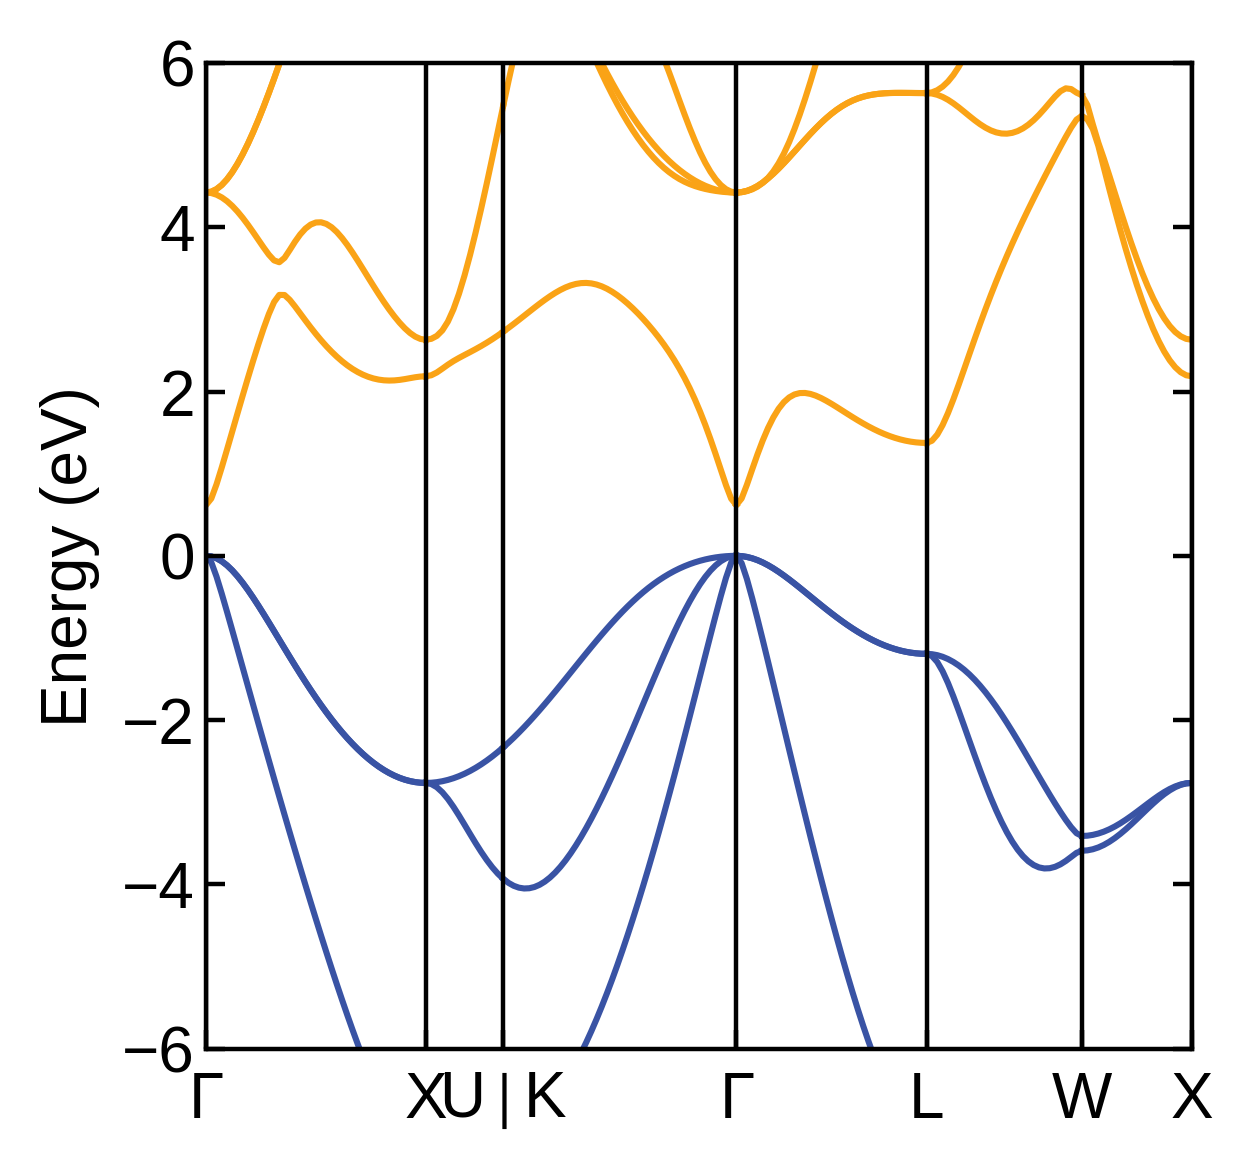

In [139]:
plotter = get_sumo_bands_plotter(bd_dzp_ecut2000.outputs.band_structure, structure=bd_dzp_ecut2000.outputs.primitive_structure)
plotter.get_plot()

<module 'matplotlib.pyplot' from '/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/matplotlib/pyplot.py'>

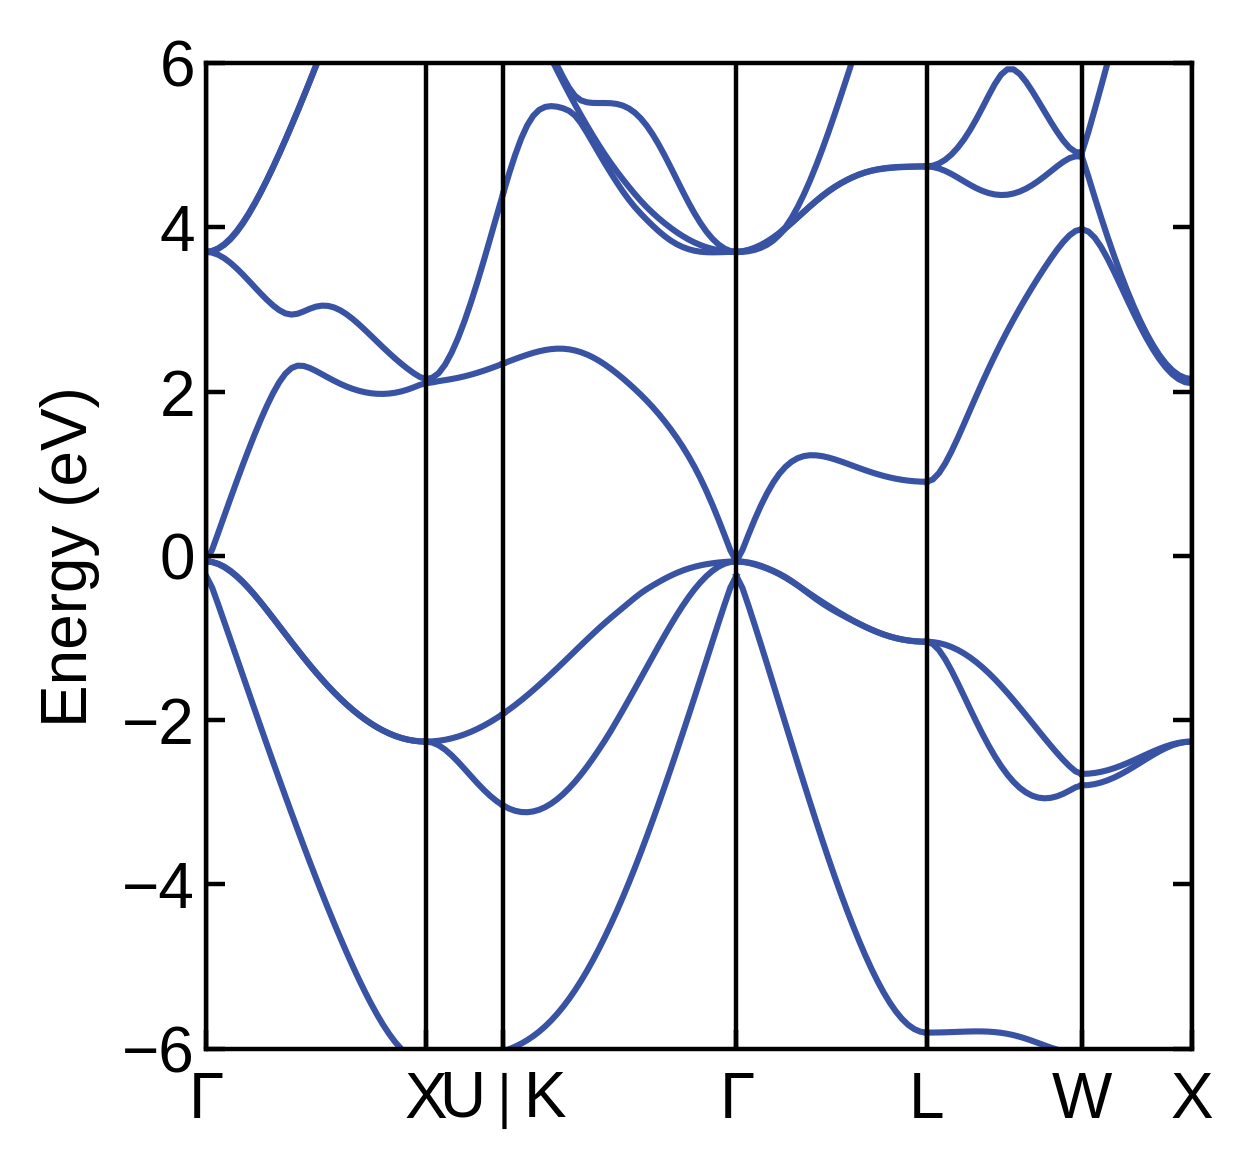

In [146]:
plotter = get_sumo_bands_plotter(load_node(658605).outputs.band_structure, structure=load_node(658605).outputs.primitive_structure)
plotter.get_plot()

In [92]:
plotter.bs.get_band_gap()

{'direct': True, 'transition': '\\Gamma-\\Gamma', 'energy': 0.6186700000000007}